# 실습 1: 이미지 분류

## 1) Ultralytics 버전

In [1]:
# 설치 uv pip install git+https://github.com/ultralytics/CLIP.git (FastSAM 실습하면서 설치됨)

### 모델 불러오기

In [4]:
import clip
import torch
from PIL import Image

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model, preprocess = clip.load('ViT-B/32', device=device)

### 이미지/텍스트 준비하기

In [5]:
image_path = './images/dog.jpeg'
classes = ['a person', 'a car', 'a dog', 'a cat']

img = Image.open(image_path)

### 모델에 넣을 준비

In [7]:
image = preprocess(img).unsqueeze(0).to(device)
text = clip.tokenize(classes).to(device)

### 유사도 계산하기

In [13]:
with torch.no_grad():
    logits_per_image, _ = model(image, text)
    print(logits_per_image)
    print('='*50)
    print(_)
    probs = logits_per_image.softmax(dim=-1).cpu().numpy()[0]

tensor([[21.5625, 20.6719, 26.0938, 20.0469]], device='cuda:0',
       dtype=torch.float16)
tensor([[21.5625],
        [20.6719],
        [26.0938],
        [20.0469]], device='cuda:0', dtype=torch.float16)


### 결과

In [15]:
for label, prob in zip(classes, probs):
    print(f'{label}: {prob:.4f}')

a person: 0.0106
a car: 0.0043
a dog: 0.9829
a cat: 0.0023


### unsqueeze란?

In [12]:
import torch

x1 = torch.tensor([1.0, 2.0, 3.0])
print(x1.shape)

x2 = x1.unsqueeze(0)
print(x2)
print(x2.shape)

torch.Size([3])
tensor([[1., 2., 3.]])
torch.Size([1, 3])


## 2) HuggingFace 버전

In [16]:
# https://huggingface.co/openai/clip-vit-base-patch32

### 모델 불러오기

In [18]:
from transformers import CLIPProcessor, CLIPModel

model = CLIPModel.from_pretrained('openai/clip-vit-base-patch32')
processor = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')

config.json: 0.00B [00:00, ?B/s]

c:\potenup3\03-utilizing-huggingface\.venv\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\user\.cache\huggingface\hub\models--openai--clip-vit-base-patch32. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

### 이미지/텍스트 준비하기

In [26]:
from PIL import Image

image_path = './images/sit.jpg'
classes = [
    'a person standing',
    'a person sitting', 
    'a person running'
]

img = Image.open(image_path)

### 모델에 넣을 준비

In [27]:
inputs = processor(
    text=classes,
    images=img,
    return_tensors='pt',
    padding=True
)

### 유사도 계산하기

In [28]:
outputs = model(**inputs)
logits_per_image = outputs.logits_per_image
probs = logits_per_image.softmax(dim=1)

In [29]:
print(probs)

tensor([[0.4514, 0.5233, 0.0253]], grad_fn=<SoftmaxBackward0>)


In [30]:
for label, prob in zip(classes, probs[0]):
    print(f"{label}: {prob:.4f}")

a person standing: 0.4514
a person sitting: 0.5233
a person running: 0.0253


In [31]:
max_idx = probs[0].argmax()
print(max_idx)
result = classes[max_idx]
print(result)

tensor(1)
a person sitting


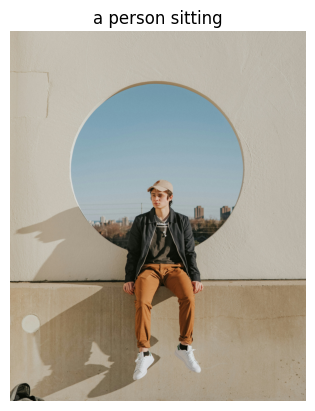

In [32]:
import matplotlib.pyplot as plt 

plt.imshow(img)
plt.title(result)
plt.axis("off")
plt.show()

# 실습 2: 이미지 검색

### 모델 불러오기

In [ ]:
import torch
from transformers import CLIPProcessor, CLIPModel

model = CLIPModel.from_pretrained('openai/clip-vit-base-patch32')
processor = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05,

### 검색어 및 검색 대상 폴더 불러오기

In [3]:
import os

image_folder = './images/clothes'

files = []

allow_extensions = ['jpg', 'jpeg', 'png', 'webp']
for file in os.listdir(image_folder):
    if file.split('.')[-1].lower() in allow_extensions:
        files.append(os.path.join(image_folder, file))
        
print(files)

['./images/clothes\\image1.jpg', './images/clothes\\image2.jpg', './images/clothes\\image3.jpg', './images/clothes\\image4.jpg', './images/clothes\\image5.jpg']


### 폴더 이미지 벡터화하기

In [5]:
from PIL import Image

image_features = []

for file in files:
    image = Image.open(file)
    inputs = processor(images=image, return_tensors='pt').to(device)
    with torch.no_grad():
        feature = model.vision_model(pixel_values=inputs['pixel_values']).pooler_output
        feature = model.visual_projection(feature)
        feature /= feature.norm(dim=-1, keepdim=True)
    
    image_features.append(feature.cpu())
    
image_features = torch.cat(image_features, dim=0)

### 검색하기

In [23]:
# 검색 설정
query = 'a blue shirt'
top_k = 3

In [24]:
# 텍스트 벡터화
inputs = processor(
    text=[query],
    return_tensors='pt'
).to(device)

with torch.no_grad():
    text_feature = model.text_model(
        input_ids=inputs['input_ids'],
        attention_mask=inputs['attention_mask']
    ).pooler_output
    text_feature = model.text_projection(text_feature)
    text_feature /= text_feature.norm(dim=-1, keepdim=True)

In [25]:
# 유사도 계산
similarity = (image_features @ text_feature.cpu().T).squeeze(1)
top_indices = similarity.argsort(descending=True)[:top_k]

print(top_indices)

tensor([4, 3, 1])


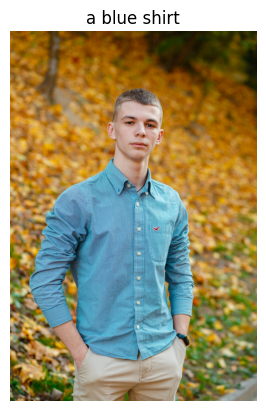

In [27]:
import matplotlib.pyplot as plt 

img = Image.open(files[4])

plt.imshow(img)
plt.title(query)
plt.axis("off")
plt.show()

# 실습 3: 모델 융합(YOLO + CLIP)

In [28]:
# 나는 이미지에서 사람이 앉아있는지 아닌지를 분류하고 싶습니다.
# sit.jpg 준비
# YOLO로 person 찾기
# CLIP실습 1을 활용해서 person 분류하기

### 모델 불러오기

In [29]:
from ultralytics import YOLO

yolo_model = YOLO('./models/yolo26n.pt')

In [31]:
from transformers import CLIPProcessor, CLIPModel
clip_model = CLIPModel.from_pretrained('openai/clip-vit-base-patch32')
processor = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [32]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
yolo_model = yolo_model.to(device)
clip_model = clip_model.to(device)

### 이미지/텍스트 준비하기

In [33]:
from PIL import Image

image_path = './images/sit.jpg'
classes = [
    'a person standing',
    'a person sitting'
]

### YOLO로 객체 감지하기

In [34]:
yolo_result = yolo_model(source=image_path)[0]
yolo_result


image 1/1 c:\potenup3\03-utilizing-huggingface\images\sit.jpg: 640x512 1 person, 121.5ms
Speed: 7.8ms preprocess, 121.5ms inference, 35.3ms postprocess per image at shape (1, 3, 640, 512)


ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant',

In [50]:
names = yolo_result.names
boxes = yolo_result.boxes

person_list = []
for data in boxes.data:
    x1, y1, x2, y2, conf, idx = data.to('cpu')
    if names[int(idx)] == 'person':
        person_list.append(data)


### 객체 감지한 결과에서 CLIP으로 분류하기

In [ ]:
from PIL import Image

image = Image.open(image_path)
for data in person_list:
    x1, y1, x2, y2, *rest = data
    crop_image = image.crop((int(x1), int(y1), int(x2), int(y2)))
    
    inputs = processor(
        text=classes,
        images=crop_image,
        return_tensors='pt',
        padding=True
    ).to(device)
    
    with torch.no_grad():
        output = clip_model(**inputs)
        logits_per_image = output.logits_per_image
        probs = logits_per_image.softmax(dim=-1).cpu().numpy()[0]
    
    best = classes[probs.argmax()]
    print(f'{best} {probs.max():.4f}')    

a person sitting 0.5386
